This notebook checks a few items for physical consistency in the prediction.

In [3]:
import numpy as np
import xarray as xr
import os
from matplotlib import pyplot as plt
from tqdm import tqdm
from wavediffusion.waveana import assemble 
import cartopy.crs as ccrs
%load_ext autoreload
%autoreload 2

# Open a random raw file to get lat and lon
ds = xr.open_dataset('/global/homes/j/jiarongw/scratch_folder/wave_data/raw/LOPS_WW3-GLOB-30M_202109.nc')
lat_deg = ds.latitude[1:-2].values
lon_deg = ds.longitude.values

### Analysis of Hs gradient (not used)

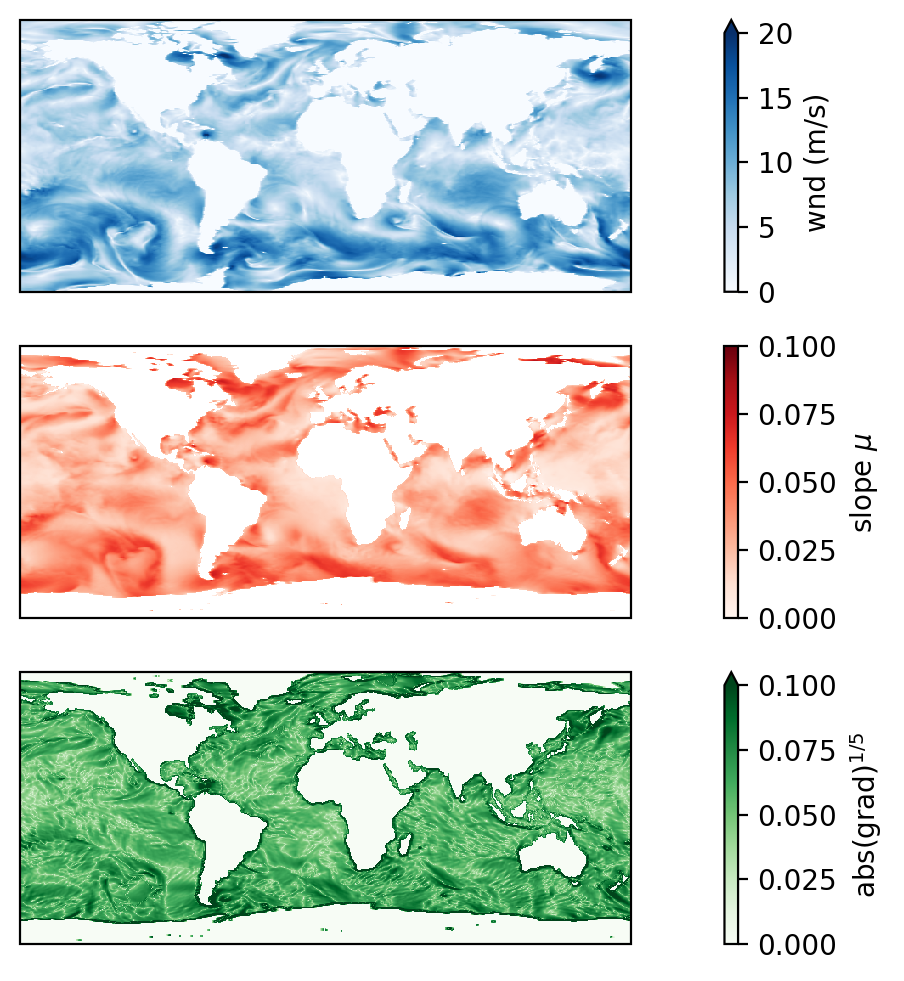

In [32]:
path = '/global/homes/j/jiarongw/wavediffusion/example/temp/200409_DDPM_40steps_100_20ensem_0.5d/'

index = 28
x_truth = np.load(f'{path}truth_{index}.npy')
x_mean = np.load(f'{path}mean_{index}.npy')
f = np.load(f'{path}forcing_{index}.npy')
truth = assemble(x_truth[0], x_truth[1], x_truth[2], (f[0]**2+f[1]**2)**0.5, f[2])
mean = assemble(x_mean[0], x_mean[1], x_mean[2], (f[0]**2+f[1]**2)**0.5, f[2])

fig, axes = plt.subplots(3, 1, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[12,6], dpi=200)
truth.slope.plot(ax=axes[1], vmin=0, vmax=0.1, cmap='Reds', transform=ccrs.PlateCarree(), cbar_kwargs={'label': r'slope $\mu$'})
truth.wnd.plot(ax=axes[0],  vmin=0, vmax=20, cmap='Blues', transform=ccrs.PlateCarree(), cbar_kwargs={'label': 'wnd (m/s)'})
field = abs(truth.grad) ** 0.2
field.plot(ax=axes[2], vmax=0.1, vmin=0, cmap='Greens', transform=ccrs.PlateCarree(), cbar_kwargs={'label': 'abs(grad)$^{1/5}$'})

### MSS v.s. wind speed

In [4]:
# Sample scenario to analyze 2004_DDPM_40steps_100_20ensem_extra
path = '/pscratch/sd/j/jiarongw/final/temp/OPTION2_sigma100_epoch8_200404/'
index = 40
x_truth = np.load(f'{path}truth_{index}.npy')
forcing = np.load(f'{path}forcing_{index}.npy')

/tmp/ipykernel_2045206/3081213744.py:23: RuntimeWarning: divide by zero encountered in log
  MSS_ = 0.0046*np.log((2*np.pi/.3)*U_*U_/9.8)


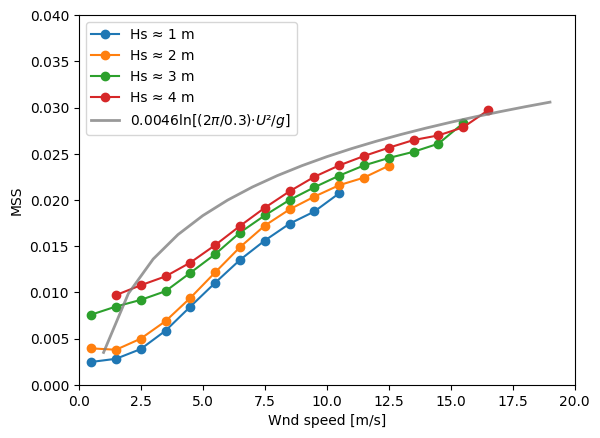

In [12]:
from scipy.stats import binned_statistic_2d

wnd = (forcing[0]**2 + forcing[1]**2) ** 0.5
mask = (forcing[-1] == 0)

U   = wnd[mask].flatten()
Hs  = x_truth[0][mask].flatten()
MSS = (x_truth[3][mask] + x_truth[4][mask]).flatten()

u_edges = np.linspace(0, 20, 21)          # 20 wind bins
u_ctr   = 0.5 * (u_edges[:-1] + u_edges[1:])

hs_edges = np.arange(0.5, 5.5, 1)         # centers at 1,2,3,4
means, ue, he, _  = binned_statistic_2d(U, Hs, MSS, 'mean',  bins=[u_edges, hs_edges])
counts, *_        = binned_statistic_2d(U, Hs, MSS, 'count', bins=[u_edges, hs_edges])
means = np.where(counts >= 20, means, np.nan)
u_ctr  = 0.5*(ue[:-1]+ue[1:]); hs_ctr = 0.5*(he[:-1]+he[1:])
for j, h in enumerate(hs_ctr):
    plt.plot(u_ctr, means[:, j], 'o-', label=f'Hs ≈ {h:.0f} m')

U_ = np.arange(0, 20)
MSS_ = 0.0046*np.log((2*np.pi/.3)*U_*U_/9.8) 
plt.plot(U_, MSS_, lw=2, alpha=0.8, c='gray', label=r'$0.0046\ln[(2\pi/0.3)·U²/g]$')


plt.xlim([0,20]); plt.xlabel('Wnd speed [m/s]')
plt.ylim([0,0.04]) ; plt.ylabel('MSS')
plt.legend()

/tmp/ipykernel_2045206/102807434.py:28: RuntimeWarning: divide by zero encountered in log
  MSS = 0.0046*np.log((2*np.pi/.3)*U*U/9.8)


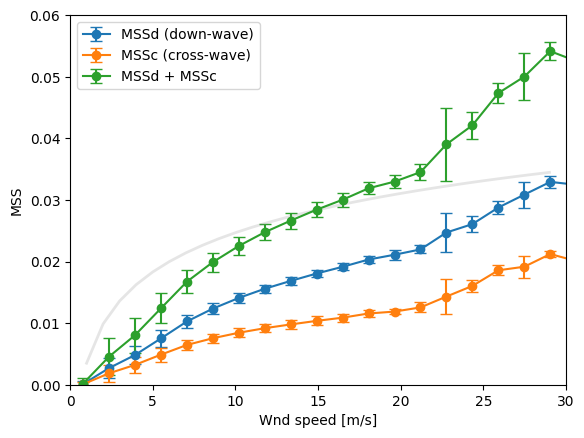

In [16]:
wnd = (forcing[0]**2 + forcing[1]**2) ** 0.5
mask = (forcing[-1] == 0)

x = wnd[mask].flatten()
y = x_truth[3][mask].flatten()

from scipy.stats import binned_statistic
means, edges, _ = binned_statistic(x, y, statistic='mean', bins=20)
stds, edges, _ = binned_statistic(x, y, statistic='std',  bins=20)
bin_centers = 0.5 * (edges[:-1] + edges[1:])
plt.errorbar(bin_centers, means, yerr=stds, fmt='o-', capsize=4, label='MSSd (down-wave)')

y = x_truth[4][mask].flatten()
from scipy.stats import binned_statistic
means, edges, _ = binned_statistic(x, y, statistic='mean', bins=20)
stds, edges, _ = binned_statistic(x, y, statistic='std',  bins=20)
bin_centers = 0.5 * (edges[:-1] + edges[1:])
plt.errorbar(bin_centers, means, yerr=stds, fmt='o-', capsize=4, label='MSSc (cross-wave)')

y = x_truth[3][mask].flatten() + x_truth[4][mask].flatten()
from scipy.stats import binned_statistic
means, edges, _ = binned_statistic(x, y, statistic='mean', bins=20)
stds, edges, _ = binned_statistic(x, y, statistic='std',  bins=20)
bin_centers = 0.5 * (edges[:-1] + edges[1:])
plt.errorbar(bin_centers, means, yerr=stds, fmt='o-', capsize=4, label='MSSd + MSSc')

U = np.arange(0, 30)
MSS = 0.0046*np.log((2*np.pi/.3)*U*U/9.8) 
plt.plot(U, MSS, lw=2, alpha=0.2, c='gray')


plt.xlim([0,30]); plt.xlabel('Wnd speed [m/s]')
plt.ylim([0,0.06]) ; plt.ylabel('MSS')
plt.legend()

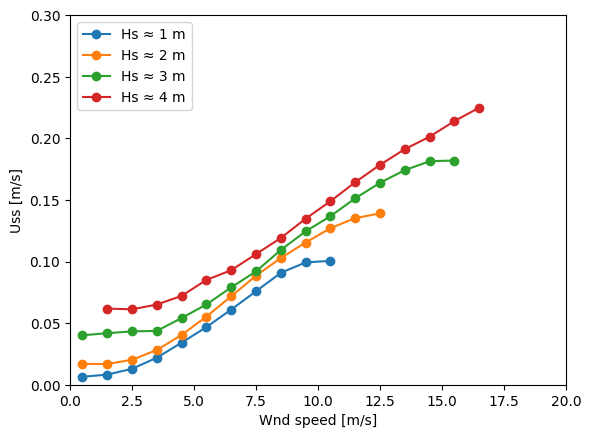

In [15]:
from scipy.stats import binned_statistic_2d

wnd = (forcing[0]**2 + forcing[1]**2) ** 0.5
mask = (forcing[-1] == 0)

U   = wnd[mask].flatten()
Hs  = x_truth[0][mask].flatten()
Uss = (x_truth[1][mask].flatten() ** 2 + x_truth[2][mask].flatten() ** 2) ** 0.5

u_edges = np.linspace(0, 20, 21)          # 20 wind bins
u_ctr   = 0.5 * (u_edges[:-1] + u_edges[1:])

hs_edges = np.arange(0.5, 5.5, 1)         # centers at 1,2,3,4
means, ue, he, _  = binned_statistic_2d(U, Hs, Uss, 'mean',  bins=[u_edges, hs_edges])
counts, *_        = binned_statistic_2d(U, Hs, Uss, 'count', bins=[u_edges, hs_edges])
means = np.where(counts >= 20, means, np.nan)
u_ctr  = 0.5*(ue[:-1]+ue[1:]); hs_ctr = 0.5*(he[:-1]+he[1:])
for j, h in enumerate(hs_ctr):
    plt.plot(u_ctr, means[:, j], 'o-', label=f'Hs ≈ {h:.0f} m')

plt.xlim([0,20]); plt.xlabel('Wnd speed [m/s]')
plt.ylim([0,0.3]); plt.ylabel('Uss [m/s]')
plt.legend()

Text(0, 0.5, 'Uss [m/s]')

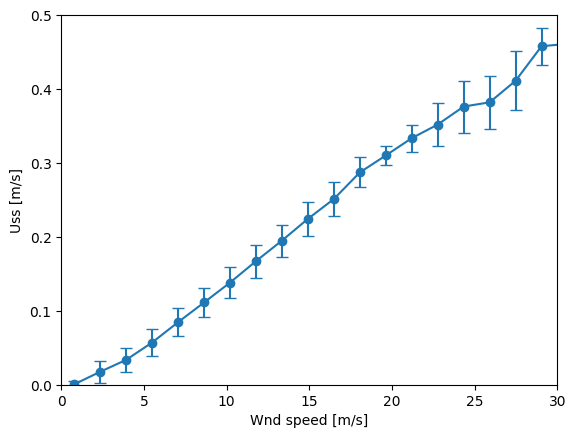

In [14]:
wnd = (forcing[0]**2 + forcing[1]**2) ** 0.5
mask = (forcing[-1] == 0)

x = wnd[mask].flatten()
y = (x_truth[1][mask].flatten() ** 2 + x_truth[2][mask].flatten() ** 2) ** 0.5
from scipy.stats import binned_statistic
means, edges, _ = binned_statistic(x, y, statistic='mean', bins=20)
stds, edges, _ = binned_statistic(x, y, statistic='std',  bins=20)
bin_centers = 0.5 * (edges[:-1] + edges[1:])
plt.errorbar(bin_centers, means, yerr=stds, fmt='o-', capsize=4)

plt.xlim([0,30]); plt.xlabel('Wnd speed [m/s]')
plt.ylim([0,0.5]); plt.ylabel('Uss [m/s]')

### Non-dimensional wave period and wave height

In [2]:
# Sample scenario to analyze
path = '/global/homes/j/jiarongw/scratch_folder/final/temp/OPTION1_moredata_sigma100_epoch20_200409/'

# for i, index in enumerate(range(0, 320, 80)):
for i, index in enumerate(range(0, 160, 40)):
    x_truth = np.load(f'{path}truth_{index}.npy')
    x_mean = np.load(f'{path}mean_{index}.npy')
    f = np.load(f'{path}forcing_{index}.npy') 
    icymask = np.load(f'{path}icymask_{index}.npy')
    if i == 0:
        truth = assemble(x_truth[0], x_truth[1], x_truth[2], (f[0]**2+f[1]**2)**0.5, icymask)
        mean = assemble(x_mean[0], x_mean[1], x_mean[2], (f[0]**2+f[1]**2)**0.5, icymask)
    else:
        t = assemble(x_truth[0], x_truth[1], x_truth[2], (f[0]**2+f[1]**2)**0.5, icymask)
        m = assemble(x_mean[0], x_mean[1], x_mean[2], (f[0]**2+f[1]**2)**0.5, icymask)
        truth = xr.concat([truth, t], dim="time")
        mean = xr.concat([mean, m], dim="time")

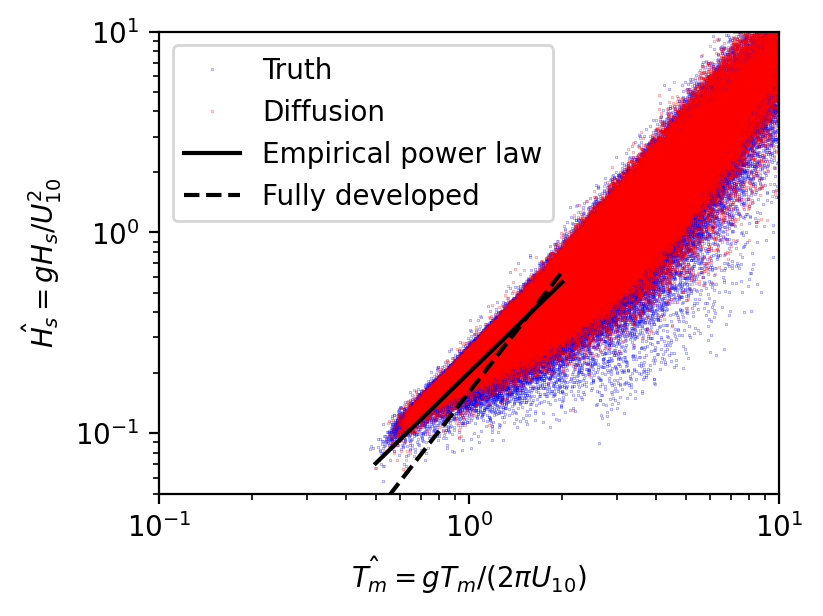

In [4]:
plt.figure(figsize=[4,3], dpi=200)

tp_hat = truth.tp_hat.where(truth.ice==1, drop=True).values.flatten()
hs_hat = truth.hs_hat.where(truth.ice==1, drop=True).values.flatten()
plt.plot(tp_hat, hs_hat, 'o', markersize=0.1, c='blue', label='Truth')
tp_hat = mean.tp_hat.where(truth.ice==1, drop=True).values.flatten()
hs_hat = mean.hs_hat.where(truth.ice==1, drop=True).values.flatten()
plt.plot(tp_hat, hs_hat, 'o', markersize=0.1, c='red', label='Diffusion')
plt.xlim([0.1, 10]); plt.ylim([0.05, 10]); plt.yscale('log'); plt.xscale('log')

# Plot some empirical relations
x = np.linspace(0.5, 2)
plt.plot(x, 0.2*x**1.5, c='k', label='Empirical power law')
plt.plot(x, 0.04*4*x**2, c='k', ls='--', label='Fully developed')

plt.xlabel(r'$\hat{T_m} = gT_m/(2\pi U_{10})$')
plt.ylabel(r'$\hat{H_s} = gH_s/U_{10}^2$')
plt.legend()

In [5]:
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
import matplotlib.colors as colors

# Grid (once)
xi_log, yi_log = np.mgrid[
    np.log10(0.5):np.log10(10):100j,
    np.log10(0.08):np.log10(10):100j
]
grid_points = np.vstack([xi_log.ravel(), yi_log.ravel()])

xi = 10**xi_log
yi = 10**yi_log

# --- Truth ---
log_right = np.log10(truth.tp_hat.where(truth.ice==1).values.flatten())
log_left = np.log10(truth.hs_hat.where(truth.ice==1).values.flatten())
mask = np.isfinite(log_left) & np.isfinite(log_right)
if mask.sum() > 0:
    print('There are NANs in truth.')
k1 = gaussian_kde([log_right[mask], log_left[mask]])
zi1 = k1(grid_points)

# --- Model ---
log_right = np.log10(mean.tp_hat.where(mean.ice==1).values.flatten())
log_left = np.log10(mean.hs_hat.where(mean.ice==1).values.flatten())
mask = np.isfinite(log_left) & np.isfinite(log_right)
if mask.sum() > 0:
    print('There are NANs in model.')
k2 = gaussian_kde([log_right[mask], log_left[mask]])
zi2 = k2(grid_points)

There are NANs in truth.
There are NANs in model.


In [ ]:
# Plot the contours
plt.figure(figsize=[4,3], dpi=200); ax = plt.gca()

# Determine contour levels based on percentile
percentiles = [0.5, 0.75, 0.90, 0.95]

zi_flat = zi1.flatten()
zi_sorted = np.sort(zi_flat)[::-1]
cumsum = np.cumsum(zi_sorted) / zi_sorted.sum()
levels1 = [zi_sorted[np.searchsorted(cumsum, p)] for p in percentiles]

zi_flat = zi2.flatten()
zi_sorted = np.sort(zi_flat)[::-1]
cumsum = np.cumsum(zi_sorted) / zi_sorted.sum()
levels2 = [zi_sorted[np.searchsorted(cumsum, p)] for p in percentiles]

# Rescale colormap
n = len(levels1)
# colors1 = plt.get_cmap('Blues')(np.linspace(0.3, 0.9, n))
# colors2 = plt.get_cmap('Reds')(np.linspace(0.3, 0.9, n))
colors1 = plt.get_cmap('Blues')(np.linspace(0.3, 0.9, n))
colors2 = plt.get_cmap('Reds')(np.linspace(0.3, 0.9, n))

# Plot
cs1 = plt.contour(xi, yi, zi1.reshape(xi.shape), colors=colors1, levels=levels1[::-1])
cs2 = plt.contour(xi, yi, zi2.reshape(xi.shape), colors=colors2, levels=levels2[::-1])
fmt1 = {level: f'{int(pct*100)}' for level, pct in zip(levels1[::-1], percentiles[::-1])}
fmt2 = {level: f'{int(pct*100)}' for level, pct in zip(levels2[::-1], percentiles[::-1])}
ax.clabel(cs1, inline=True, fontsize=8, fmt=fmt1)
ax.clabel(cs2, inline=True, fontsize=8, fmt=fmt2)

# Power law
x = np.linspace(0.5, 5)
plt.plot(x, 0.2*x**1.5, c='k')
plt.plot(x, 0.04*4*x**2, c='k', ls='--')
# Axes
plt.xlim([0.3, 10]); plt.ylim([0.05, 10]); plt.yscale('log'); plt.xscale('log')
plt.xlabel(r'$\hat{T_p} = gT_p/(2\pi U_{10})$')
plt.ylabel(r'$\hat{H_s} = gH_s/U_{10}^2$')
# Legend
legend_lines = [
    Line2D([0], [0], color=plt.get_cmap('Blues')(0.5), lw=1),
    Line2D([0], [0], color=plt.get_cmap('Reds')(0.5), lw=1),
    Line2D([0], [0], color='black', lw=1),
    Line2D([0], [0], color='black', ls='--', lw=1)
]
plt.legend(legend_lines,
           ['Hindcast', 'DDPM', r'$\hat{H_s} \propto \hat{T_p}^{3/2}$', r'$\hat{H_s} \propto \hat{T_p}^{2}$'], loc='upper left')

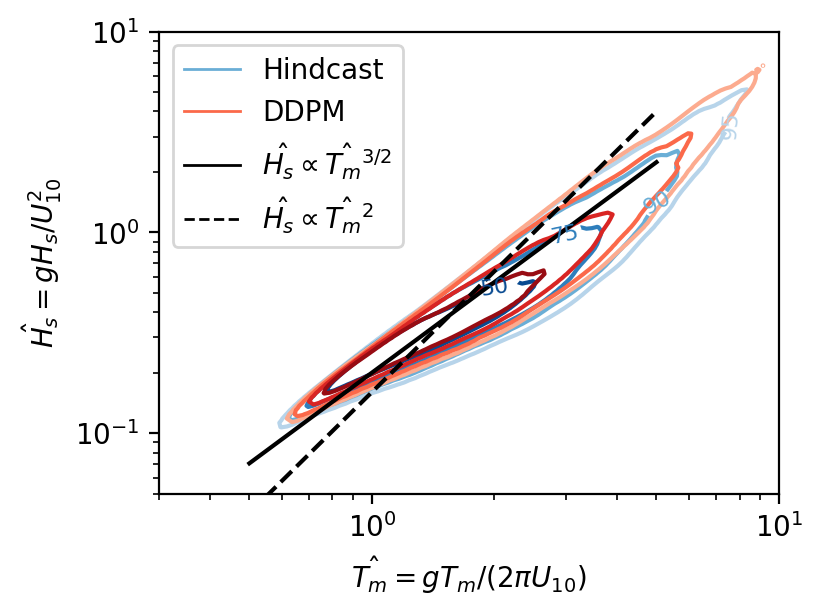

In [6]:
# Plot the contours
plt.figure(figsize=[4,3], dpi=200); ax = plt.gca()

# Determine contour levels based on percentile
percentiles = [0.5, 0.75, 0.90, 0.95]

zi_flat = zi1.flatten()
zi_sorted = np.sort(zi_flat)[::-1]
cumsum = np.cumsum(zi_sorted) / zi_sorted.sum()
levels1 = [zi_sorted[np.searchsorted(cumsum, p)] for p in percentiles]

zi_flat = zi2.flatten()
zi_sorted = np.sort(zi_flat)[::-1]
cumsum = np.cumsum(zi_sorted) / zi_sorted.sum()
levels2 = [zi_sorted[np.searchsorted(cumsum, p)] for p in percentiles]

# Rescale colormap
n = len(levels1)
# colors1 = plt.get_cmap('Blues')(np.linspace(0.3, 0.9, n))
# colors2 = plt.get_cmap('Reds')(np.linspace(0.3, 0.9, n))
colors1 = plt.get_cmap('Blues')(np.linspace(0.3, 0.9, n))
colors2 = plt.get_cmap('Reds')(np.linspace(0.3, 0.9, n))

# Plot
cs1 = plt.contour(xi, yi, zi1.reshape(xi.shape), colors=colors1, levels=levels1[::-1])
cs2 = plt.contour(xi, yi, zi2.reshape(xi.shape), colors=colors2, levels=levels1[::-1])
fmt1 = {level: f'{int(pct*100)}' for level, pct in zip(levels1[::-1], percentiles[::-1])}
fmt2 = {level: f'{int(pct*100)}' for level, pct in zip(levels1[::-1], percentiles[::-1])}
manual_positions = [
    (8.0, 3.0),   # 95% — extends furthest right
    (5.0, 1.5),   # 90%
    (3.0, 0.8),   # 75%
    (2.0, 0.5),   # 50% — innermost, doesn't reach far right
]
ax.clabel(cs1, inline=True, fontsize=8, fmt=fmt1, manual=manual_positions)
# ax.clabel(cs2, inline=True, fontsize=8, fmt=fmt2)

# Power law
x = np.linspace(0.5, 5)
plt.plot(x, 0.2*x**1.5, c='k')
plt.plot(x, 0.04*4*x**2, c='k', ls='--')
# Axes
plt.xlim([0.3, 10]); plt.ylim([0.05, 10]); plt.yscale('log'); plt.xscale('log')
plt.xlabel(r'$\hat{T_m} = gT_m/(2\pi U_{10})$')
plt.ylabel(r'$\hat{H_s} = gH_s/U_{10}^2$')
# Legend
legend_lines = [
    Line2D([0], [0], color=plt.get_cmap('Blues')(0.5), lw=1),
    Line2D([0], [0], color=plt.get_cmap('Reds')(0.5), lw=1),
    Line2D([0], [0], color='black', lw=1),
    Line2D([0], [0], color='black', ls='--', lw=1)
]
plt.legend(legend_lines,
           ['Hindcast', 'DDPM', r'$\hat{H_s} \propto \hat{T_m}^{3/2}$', r'$\hat{H_s} \propto \hat{T_m}^{2}$'], loc='upper left')
plt.savefig(f'density_contour.pdf', bbox_inches='tight')

(0.0, 14.0)

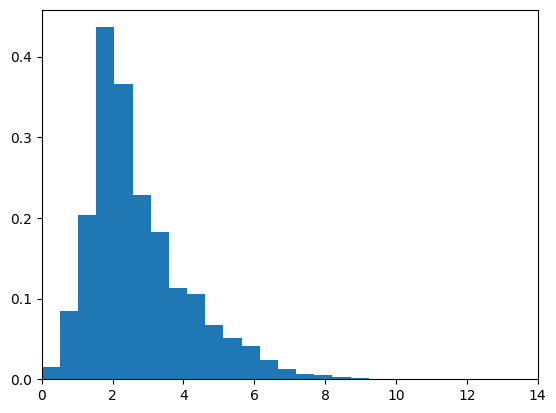

In [7]:
# Wave height distribution
plt.hist(x_truth[0][icymask], bins=np.linspace(0,20,40), density=True)
plt.xlim([0,14])

### Metrics binned with wave height

In [33]:
def binned_metrics(path, bins, PLAIN=False):
    snapshots = []
    for index in tqdm(range(0, 2880, 80)):
        x_truth  = np.load(f'{path}truth_{index}.npy')
        if PLAIN: # deterministic model
            x_pred = np.load(f'{path}pred_{index}.npy')
        else: # diffusion model
            x_pred = np.load(f'{path}mean_{index}.npy')
        forcing  = np.load(f'{path}forcing_{index}.npy')
    
        ds = xr.Dataset({
            'hs_truth': (('lat', 'lon'), x_truth[0]),
            'lp_truth': (('lat', 'lon'), x_truth[1]),
            'hs_pred':  (('lat', 'lon'), x_pred[0]),
            'lp_pred':  (('lat', 'lon'), x_pred[1]),
            'ice':      (('lat', 'lon'), forcing[2]),
        }, coords={'lat': lat_deg, 'lon': lon_deg})
        snapshots.append(ds)
    
    ds_all = xr.concat(snapshots, dim='snapshot')
    ds_ice = ds_all.where(ds_all.ice == 1, drop=True)
    ds_ice['hs_diff'] = (ds_ice.hs_truth - ds_ice.hs_pred) ** 2
    ds_ice['lp_diff'] = (ds_ice.lp_truth - ds_ice.lp_pred) ** 2
    
    bin_edges = list(bins) + [np.inf]
    grouped = ds_ice[['hs_diff', 'lp_diff']].groupby_bins(
        ds_ice.hs_truth, bins=bin_edges, right=False
    )
    n_count = grouped.count().hs_diff.values
    metric1 = grouped.mean().hs_diff.values
    metric2 = grouped.mean().lp_diff.values
    
    return n_count, metric1, metric2

In [34]:
path1 = '/global/homes/j/jiarongw/wavediffusion/example/temp/2004_DDPM_40steps_100_20ensem_extra/'
path2 = '/global/homes/j/jiarongw/wavediffusion/example/temp/plain_2004/'
bins = (0, 1, 2, 3, 4, 5, 6, 8)
n_count, hs_mse, lp_mse = binned_metrics(path1, bins)
n_count_plain, hs_mse_plain, lp_mse_plain = binned_metrics(path2, bins, PLAIN=True)

100%|██████████| 36/36 [00:02<00:00, 16.87it/s]


In [24]:
print(n_count, n_count_plain)

[ 26553 173651 177897  82294  42858  20535  12310   1743] [ 26553 173651 177897  82294  42858  20535  12310   1743]


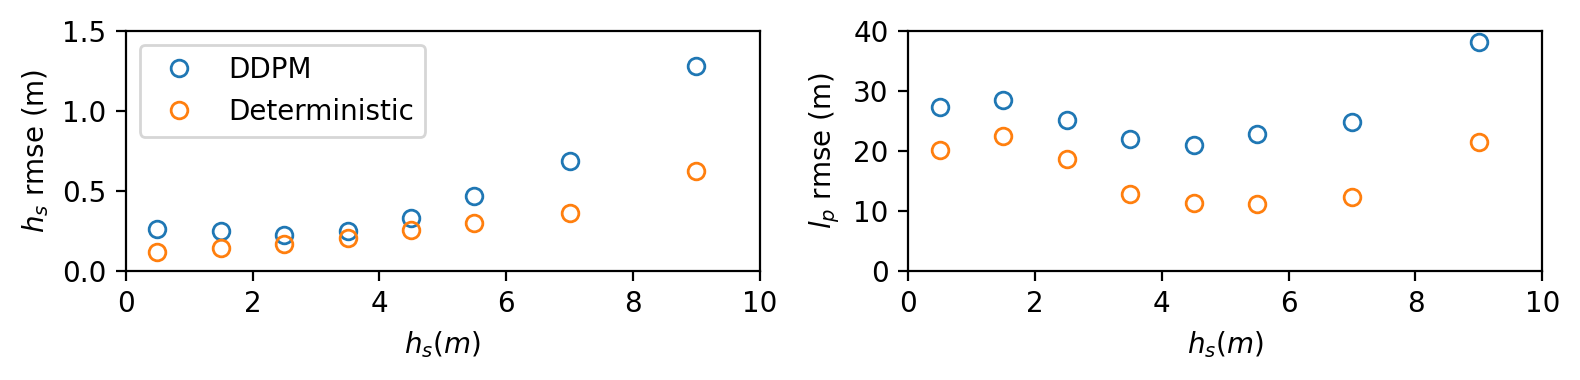

In [40]:
fig, axes = plt.subplots(1, 2, figsize=[8,2], dpi=200)
bin_centers = [(a + b) / 2 for a, b in zip(bins[:-1], bins[1:])]
bin_centers.append(bins[-1] + 1)
axes[0].plot(bin_centers, hs_mse**0.5, 'o', mfc='none', label='DDPM')
axes[0].plot(bin_centers, hs_mse_plain**0.5, 'o', mfc='none', label='Deterministic')
axes[1].plot(bin_centers, lp_mse**0.5, 'o', mfc='none', label='DDPM')
axes[1].plot(bin_centers, lp_mse_plain**0.5, 'o', mfc='none', label='Deterministic')
axes[0].set_ylim([0,1.5]); axes[0].set_xlim([0,10]); axes[0].set_xlabel(r'$h_s (m)$'); axes[0].set_ylabel(r'$h_s$ rmse (m)')
axes[1].set_ylim([0,40]); axes[1].set_xlim([0,10]); axes[1].set_xlabel(r'$h_s (m)$'); axes[1].set_ylabel(r'$l_p$ rmse (m)')
axes[0].legend()
plt.tight_layout()